In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
PROJECT_ROOT = Path(r"C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x")

print("Project root:", PROJECT_ROOT)
print("Exists:", PROJECT_ROOT.exists())

Project root: C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x
Exists: True


In [3]:
sys.path.append(str(PROJECT_ROOT))

from src.eda.eda_utils import (
    load_dataset,
    dataset_summary,
    label_distribution
)

print("EDA utilities imported successfully")

EDA utilities imported successfully


In [4]:
DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "phishguard_features_final_11500.csv"
)

df = load_dataset(DATA_FILE)

print("Final dataset loaded successfully")
print("Shape:", df.shape)

Final dataset loaded successfully
Shape: (11500, 18)


In [6]:
# STEP 30: DATASET SUMMARY

print("========== DATASET SUMMARY ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nLabel distribution:")
print(df["Label"].value_counts())

========== DATASET SUMMARY ==========
Rows: 11500
Columns: 18

Data types:
Domain             str
Have_IP          int64
Have_At          int64
URL_Length       int64
URL_Depth        int64
Redirection      int64
https_Domain     int64
TinyURL          int64
Prefix/Suffix    int64
DNS_Record       int64
Web_Traffic      int64
Domain_Age       int64
Domain_End       int64
iFrame           int64
Mouse_Over       int64
Right_Click      int64
Web_Forwards     int64
Label            int64
dtype: object

Missing values:
Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64

Duplicate rows:
6170

Label distribution:
Label
0    6500
1    5000
Name: count, dtype: int64


In [5]:
df.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,metro.co.uk,0,0,1,4,0,0,0,0,0,1,1,1,1,0,1,0,0
1,techcrunch.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
2,olx.ua,0,0,1,4,0,0,0,0,0,1,0,0,1,0,1,0,0
3,bdnews24.com,0,0,1,5,0,0,0,0,0,1,0,1,1,0,1,0,0
4,udn.com,0,0,1,4,0,0,0,0,0,1,0,1,1,0,1,0,0


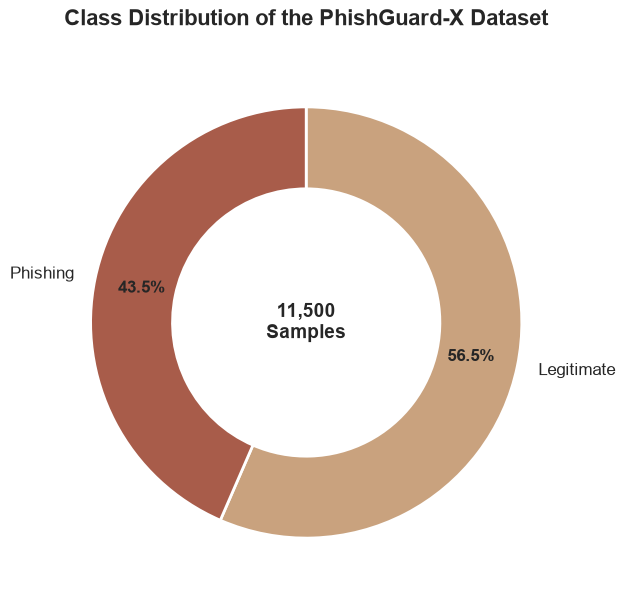

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\class_distribution_donut.png


In [8]:
# STEP 31: CLASS DISTRIBUTION
# Display + save the figure

from pathlib import Path

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

label_counts = df["Label"].value_counts().sort_index()

labels = ["Legitimate", "Phishing"]
values = [
    label_counts.get(0, 0),
    label_counts.get(1, 0)
]

# Warm professional palette
warm_palette = ["#C9A27E", "#A85C4A"]

sns.set_theme(
    style="white",
    font_scale=1.1
)

fig, ax = plt.subplots(figsize=(8, 7))

donut_wedges, donut_texts, donut_autotexts = ax.pie(
    values,
    labels=labels,
    colors=warm_palette,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.38,
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 12
    }
)

for autotext in donut_autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

ax.text(
    0,
    0,
    f"{sum(values):,}\nSamples",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold"
)

ax.set_title(
    "Class Distribution of the PhishGuard-X Dataset",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Save high-resolution figure
output_file = FIGURE_DIR / "class_distribution_donut.png"

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_file)

In [9]:
print("========== UNIQUE VALUES ==========")

for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

========== UNIQUE VALUES ==========
Domain: 4942 unique values
Have_IP: 2 unique values
Have_At: 2 unique values
URL_Length: 2 unique values
URL_Depth: 16 unique values
Redirection: 2 unique values
https_Domain: 2 unique values
TinyURL: 2 unique values
Prefix/Suffix: 2 unique values
DNS_Record: 2 unique values
Web_Traffic: 2 unique values
Domain_Age: 2 unique values
Domain_End: 2 unique values
iFrame: 2 unique values
Mouse_Over: 2 unique values
Right_Click: 1 unique values
Web_Forwards: 2 unique values
Label: 2 unique values


In [10]:
print("========== UNIQUE VALUE DETAILS ==========")

for column in df.columns:
    if column != "Domain":
        print(f"\n{column}:")
        print(sorted(df[column].unique()))

========== UNIQUE VALUE DETAILS ==========

Have_IP:
[np.int64(0), np.int64(1)]

Have_At:
[np.int64(0), np.int64(1)]

URL_Length:
[np.int64(0), np.int64(1)]

URL_Depth:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(14), np.int64(16), np.int64(17), np.int64(28)]

Redirection:
[np.int64(0), np.int64(1)]

https_Domain:
[np.int64(0), np.int64(1)]

TinyURL:
[np.int64(0), np.int64(1)]

Prefix/Suffix:
[np.int64(0), np.int64(1)]

DNS_Record:
[np.int64(0), np.int64(1)]

Web_Traffic:
[np.int64(0), np.int64(1)]

Domain_Age:
[np.int64(0), np.int64(1)]

Domain_End:
[np.int64(0), np.int64(1)]

iFrame:
[np.int64(0), np.int64(1)]

Mouse_Over:
[np.int64(0), np.int64(1)]

Right_Click:
[np.int64(1)]

Web_Forwards:
[np.int64(0), np.int64(1)]

Label:
[np.int64(0), np.int64(1)]


In [12]:
print("========== DESCRIPTIVE STATISTICS ==========")

display(df.describe().T)

========== DESCRIPTIVE STATISTICS ==========


,count,mean,std,min,25%,50%,75%,max
Have_IP,11500.0,0.000783,0.027965,0.0,0.0,0.0,0.0,1.0
Have_At,11500.0,0.004522,0.067095,0.0,0.0,0.0,0.0,1.0
URL_Length,11500.0,0.542870,0.498180,0.0,0.0,1.0,1.0,1.0
URL_Depth,11500.0,1.930783,2.086254,0.0,0.0,1.0,3.0,28.0
Redirection,11500.0,0.013043,0.113466,0.0,0.0,0.0,0.0,1.0
https_Domain,11500.0,0.000087,0.009325,0.0,0.0,0.0,0.0,1.0
TinyURL,11500.0,0.063217,0.243364,0.0,0.0,0.0,0.0,1.0
Prefix/Suffix,11500.0,0.162783,0.369183,0.0,0.0,0.0,0.0,1.0
DNS_Record,11500.0,0.135304,0.342063,0.0,0.0,0.0,0.0,1.0
Web_Traffic,11500.0,0.736783,0.440399,0.0,0.0,1.0,1.0,1.0


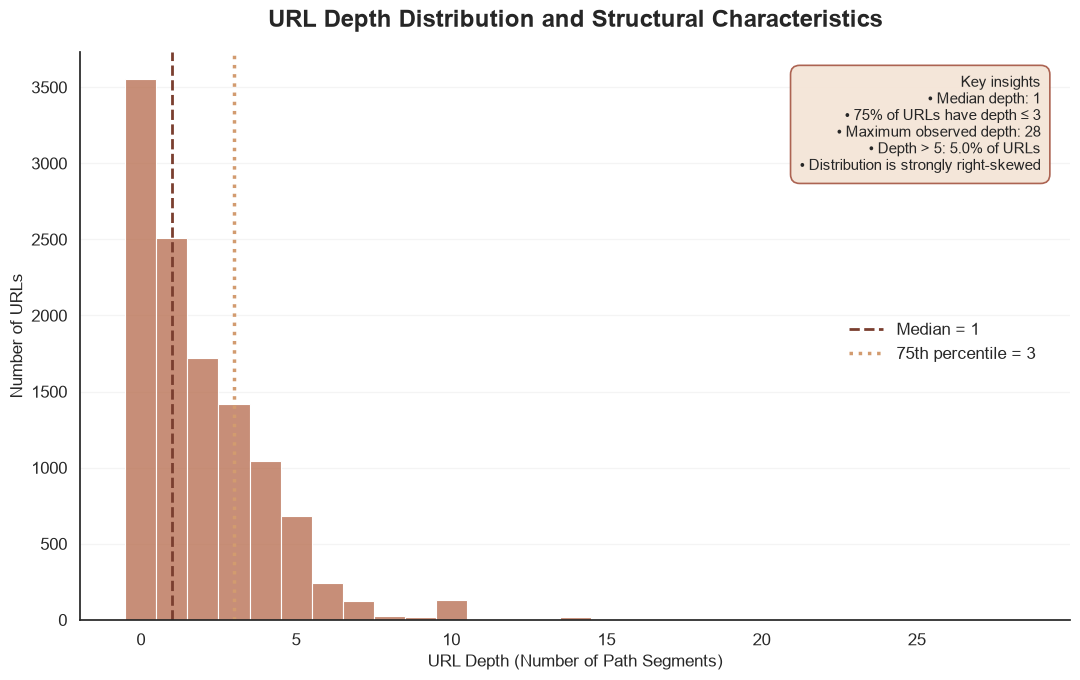

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\url_depth_distribution_research.png

========== URL DEPTH INSIGHTS ==========
Median depth: 1
75th percentile: 3
Maximum depth: 28
URLs with depth > 5: 4.97%


In [14]:
# STEP 34: RESEARCH-STYLE URL DEPTH ANALYSIS
# Display + save

url_depth = df["URL_Depth"]

median_depth = url_depth.median()
q75_depth = url_depth.quantile(0.75)
max_depth = url_depth.max()

# High-depth URLs: depth > 5
high_depth_pct = (url_depth.gt(5).mean()) * 100

fig, ax = plt.subplots(figsize=(11, 7))

sns.histplot(
    data=df,
    x="URL_Depth",
    discrete=True,
    color="#B86F52",
    alpha=0.78,
    edgecolor="white",
    linewidth=0.8,
    ax=ax
)

# Median
ax.axvline(
    median_depth,
    color="#7A3E2F",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_depth:.0f}"
)

# 75th percentile
ax.axvline(
    q75_depth,
    color="#D29B6F",
    linestyle=":",
    linewidth=2.5,
    label=f"75th percentile = {q75_depth:.0f}"
)

# Title
ax.set_title(
    "URL Depth Distribution and Structural Characteristics",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "URL Depth (Number of Path Segments)",
    fontsize=12
)

ax.set_ylabel(
    "Number of URLs",
    fontsize=12
)

# Research insight box
insight_text = (
    f"Key insights\n"
    f"• Median depth: {median_depth:.0f}\n"
    f"• 75% of URLs have depth ≤ {q75_depth:.0f}\n"
    f"• Maximum observed depth: {max_depth:.0f}\n"
    f"• Depth > 5: {high_depth_pct:.1f}% of URLs\n"
    f"• Distribution is strongly right-skewed"
)

ax.text(
    0.97,
    0.96,
    insight_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#F4E5D7",
        edgecolor="#A85C4A",
        linewidth=1.2,
        alpha=0.95
    )
)

ax.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(0.98, 0.55)
)

ax.grid(
    axis="y",
    alpha=0.20
)

sns.despine()

plt.tight_layout()

output_file = FIGURE_DIR / "url_depth_distribution_research.png"

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully:")
print(output_file)

print("\n========== URL DEPTH INSIGHTS ==========")
print(f"Median depth: {median_depth:.0f}")
print(f"75th percentile: {q75_depth:.0f}")
print(f"Maximum depth: {max_depth:.0f}")
print(f"URLs with depth > 5: {high_depth_pct:.2f}%")

C:\Users\nk134\AppData\Local\Temp\ipykernel_7676\736679204.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


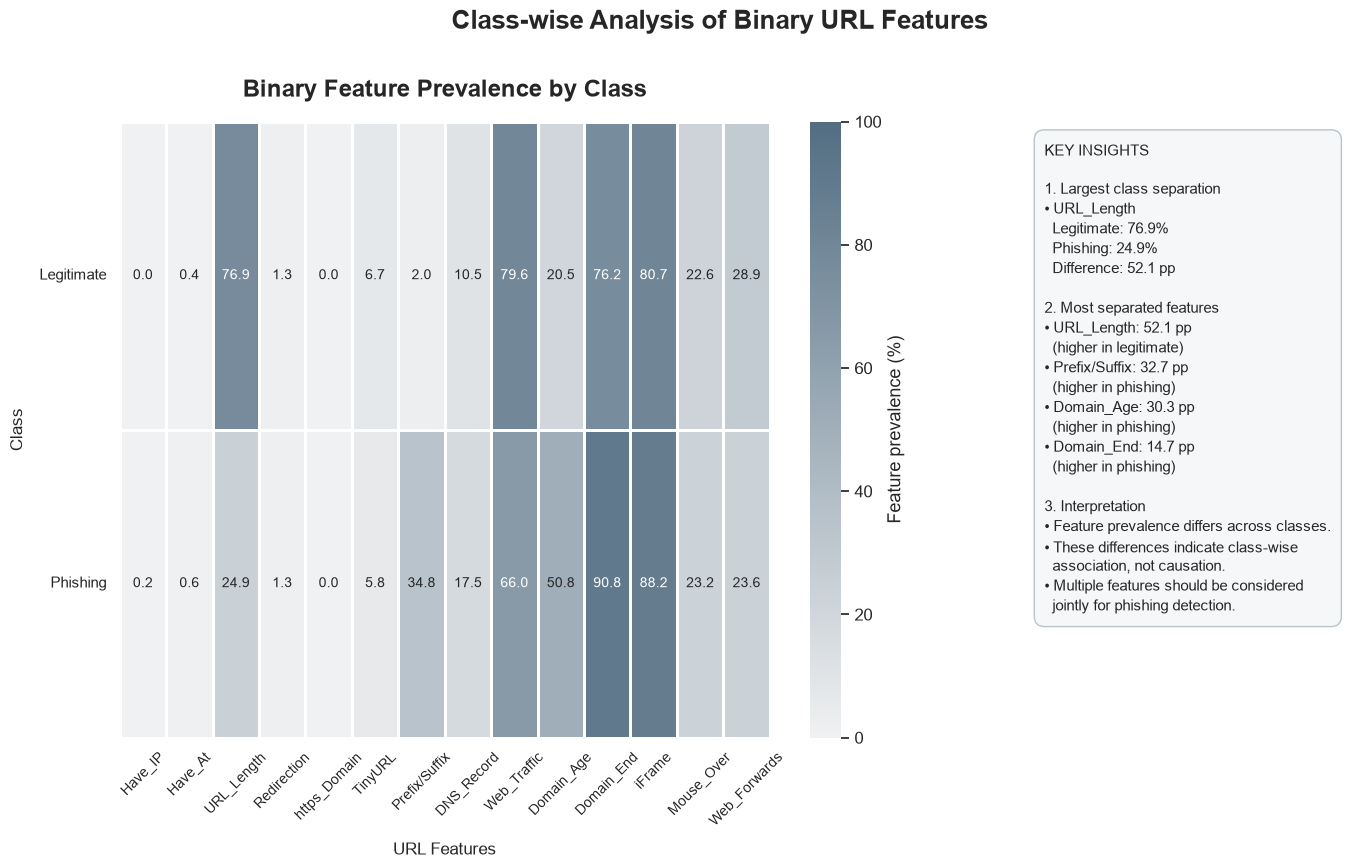

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\binary_feature_prevalence_by_class_research.png

========== CLASS-WISE FEATURE SEPARATION ==========
URL_Length: Legitimate=76.92%, Phishing=24.86%, Difference=52.06 pp
Prefix/Suffix: Legitimate=2.05%, Phishing=34.78%, Difference=32.73 pp
Domain_Age: Legitimate=20.52%, Phishing=50.80%, Difference=30.28 pp
Domain_End: Legitimate=76.18%, Phishing=90.84%, Difference=14.66 pp


In [16]:
# STEP 35: RESEARCH-STYLE BINARY FEATURE PREVALENCE
# Display + save

binary_features = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards"
]

# --------------------------------------------------
# 1. Calculate feature prevalence by class
# --------------------------------------------------

prevalence = (
    df.groupby("Label")[binary_features]
      .mean()
      .mul(100)
)

prevalence.index = ["Legitimate", "Phishing"]

# Difference: Phishing - Legitimate
difference = (
    prevalence.loc["Phishing"]
    - prevalence.loc["Legitimate"]
)

# Sort features by absolute class separation
ranked_features = (
    difference.abs()
    .sort_values(ascending=False)
)

top_features = ranked_features.index[:4]

# --------------------------------------------------
# 2. Create figure layout
# --------------------------------------------------

fig = plt.figure(figsize=(16, 8))

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[4.5, 1.8],
    wspace=0.18
)

ax = fig.add_subplot(gs[0, 0])
insight_ax = fig.add_subplot(gs[0, 1])

# --------------------------------------------------
# 3. Subtle academic color palette
# --------------------------------------------------

academic_cmap = sns.light_palette(
    "#526D82",
    as_cmap=True
)

# --------------------------------------------------
# 4. Heatmap
# --------------------------------------------------

sns.heatmap(
    prevalence,
    annot=True,
    fmt=".1f",
    cmap=academic_cmap,
    vmin=0,
    vmax=100,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={
        "label": "Feature prevalence (%)"
    },
    annot_kws={
        "fontsize": 10
    },
    ax=ax
)

ax.set_title(
    "Binary Feature Prevalence by Class",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "URL Features",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "Class",
    fontsize=12,
    labelpad=10
)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=10
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=11
)

# --------------------------------------------------
# 5. Research insight panel
# --------------------------------------------------

insight_ax.axis("off")

# Largest separation
largest_feature = ranked_features.index[0]
largest_diff = difference[largest_feature]

legit_value = prevalence.loc[
    "Legitimate",
    largest_feature
]

phish_value = prevalence.loc[
    "Phishing",
    largest_feature
]

# Top four feature differences
top_lines = []

for feature in top_features:
    diff = difference[feature]

    direction = (
        "higher in phishing"
        if diff > 0
        else "higher in legitimate"
    )

    top_lines.append(
        f"• {feature}: {abs(diff):.1f} pp\n"
        f"  ({direction})"
    )

insight_text = (
    "KEY INSIGHTS\n\n"
    "1. Largest class separation\n"
    f"• {largest_feature}\n"
    f"  Legitimate: {legit_value:.1f}%\n"
    f"  Phishing: {phish_value:.1f}%\n"
    f"  Difference: {abs(largest_diff):.1f} pp\n\n"
    
    "2. Most separated features\n"
    + "\n".join(top_lines)
    + "\n\n"
    
    "3. Interpretation\n"
    "• Feature prevalence differs across classes.\n"
    "• These differences indicate class-wise\n"
    "  association, not causation.\n"
    "• Multiple features should be considered\n"
    "  jointly for phishing detection."
)

insight_ax.text(
    0.03,
    0.97,
    insight_text,
    transform=insight_ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="#F5F7F8",
        edgecolor="#B8C4CC",
        linewidth=1.0
    )
)

# --------------------------------------------------
# 6. Overall title
# --------------------------------------------------

fig.suptitle(
    "Class-wise Analysis of Binary URL Features",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

# --------------------------------------------------
# 7. Save figure
# --------------------------------------------------

output_file = (
    FIGURE_DIR
    / "binary_feature_prevalence_by_class_research.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# --------------------------------------------------
# 8. Print exact research statistics
# --------------------------------------------------

print("Figure saved successfully:")
print(output_file)

print("\n========== CLASS-WISE FEATURE SEPARATION ==========")

for feature in top_features:
    print(
        f"{feature}: "
        f"Legitimate={prevalence.loc['Legitimate', feature]:.2f}%, "
        f"Phishing={prevalence.loc['Phishing', feature]:.2f}%, "
        f"Difference={abs(difference[feature]):.2f} pp"
    )

C:\Users\nk134\AppData\Local\Temp\ipykernel_7676\3872765850.py:307: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


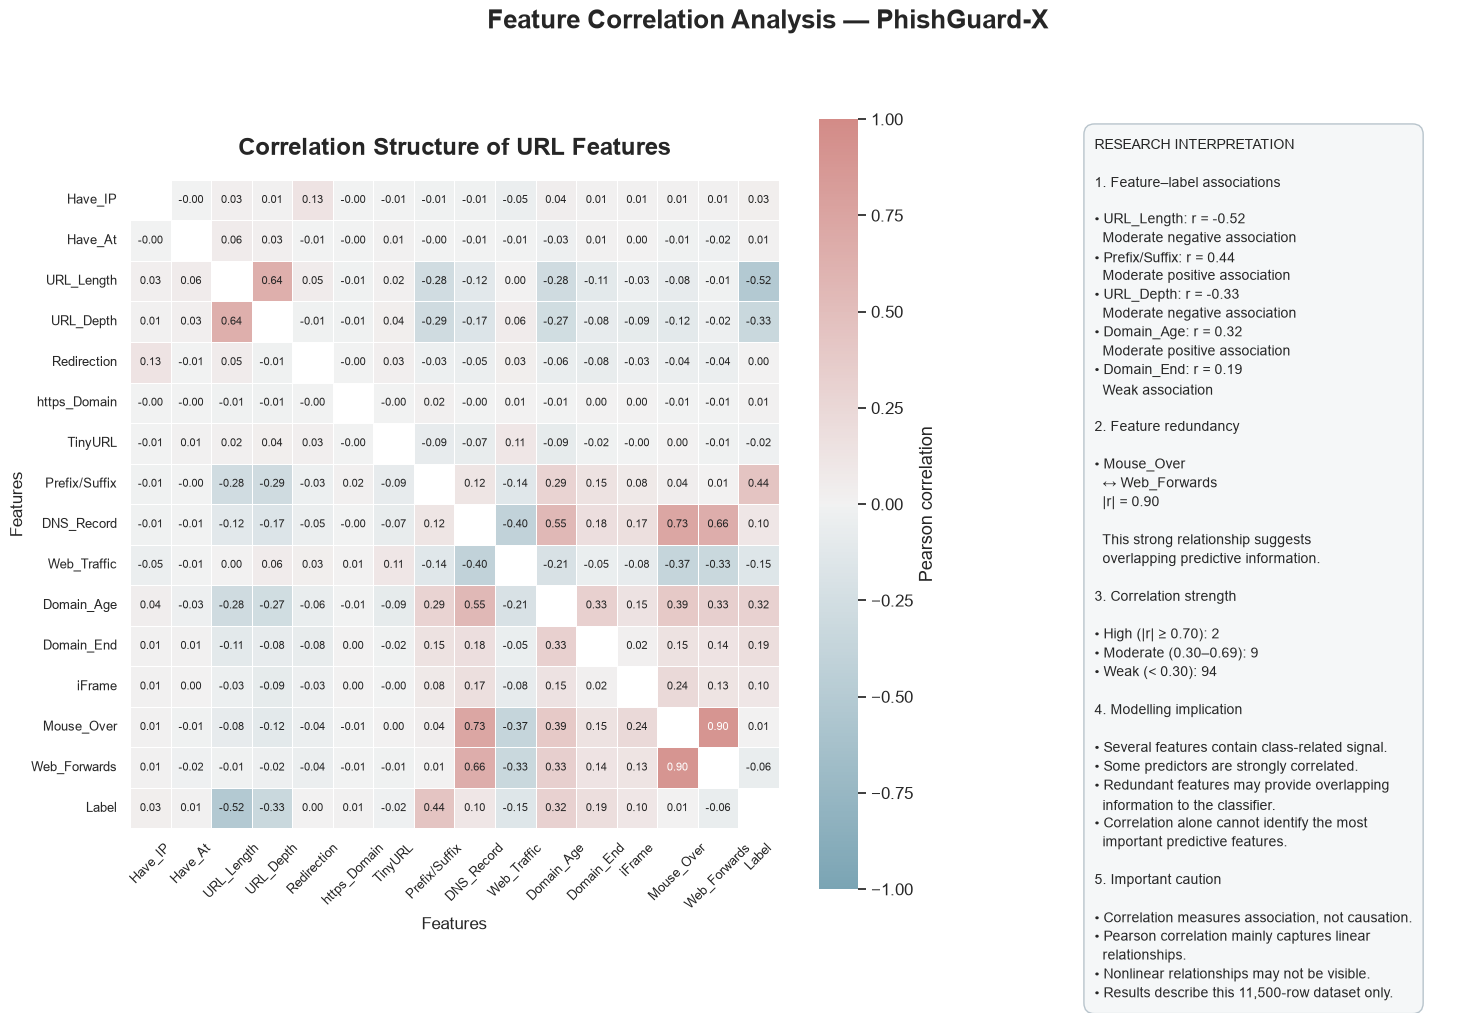

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\feature_correlation_heatmap_research.png

========== TOP FEATURE-LABEL CORRELATIONS ==========
URL_Length: r = -0.5181
Prefix/Suffix: r = 0.4396
URL_Depth: r = -0.3346
Domain_Age: r = 0.3176
Domain_End: r = 0.1914

========== STRONGEST FEATURE-FEATURE CORRELATION ==========
Mouse_Over <-> Web_Forwards: |r| = 0.9029

========== CORRELATION STRENGTH ==========
High correlations: 2
Moderate correlations: 9
Weak correlations: 94


In [19]:
# STEP 36: RESEARCH-STYLE FEATURE CORRELATION HEATMAP
# Improved interpretation + redundancy analysis

correlation_features = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards",
    "Label"
]

# --------------------------------------------------
# 1. Correlation matrix
# --------------------------------------------------

correlation_matrix = df[correlation_features].corr()

# Feature-label correlations
label_correlation = (
    correlation_matrix["Label"]
    .drop("Label")
    .sort_values(key=abs, ascending=False)
)

top_label_features = label_correlation.head(5)


# --------------------------------------------------
# 2. Find strongest UNIQUE feature-feature pair
# --------------------------------------------------

feature_only_corr = (
    correlation_matrix
    .drop(index="Label", columns="Label")
    .copy()
)

# Keep only upper triangle to avoid duplicate pairs
upper_triangle = feature_only_corr.where(
    np.triu(
        np.ones(feature_only_corr.shape),
        k=1
    ).astype(bool)
)

strongest_pairs = (
    upper_triangle.abs()
    .stack()
    .sort_values(ascending=False)
)

if len(strongest_pairs) > 0:

    strongest_feature_1 = strongest_pairs.index[0][0]
    strongest_feature_2 = strongest_pairs.index[0][1]
    strongest_value = strongest_pairs.iloc[0]

else:

    strongest_feature_1 = "N/A"
    strongest_feature_2 = "N/A"
    strongest_value = np.nan


# --------------------------------------------------
# 3. Count correlation strength categories
# --------------------------------------------------

feature_values = upper_triangle.abs().stack()

high_corr_count = (feature_values >= 0.70).sum()
moderate_corr_count = (
    (feature_values >= 0.30) &
    (feature_values < 0.70)
).sum()
weak_corr_count = (feature_values < 0.30).sum()


# --------------------------------------------------
# 4. Mask diagonal
# --------------------------------------------------

heatmap_mask = np.eye(
    correlation_matrix.shape[0],
    dtype=bool
)


# --------------------------------------------------
# 5. Figure layout
# --------------------------------------------------

fig = plt.figure(
    figsize=(17, 10)
)

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[4.5, 2.0],
    wspace=0.25
)

ax = fig.add_subplot(gs[0, 0])
insight_ax = fig.add_subplot(gs[0, 1])


# --------------------------------------------------
# 6. Professional academic color palette
# --------------------------------------------------

academic_cmap = sns.diverging_palette(
    220,
    15,
    s=45,
    l=65,
    center="light",
    as_cmap=True
)


# --------------------------------------------------
# 7. Correlation heatmap
# --------------------------------------------------

sns.heatmap(
    correlation_matrix,
    mask=heatmap_mask,
    annot=True,
    fmt=".2f",
    cmap=academic_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.6,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Pearson correlation"
    },
    annot_kws={
        "fontsize": 8
    },
    ax=ax
)


# --------------------------------------------------
# 8. Heatmap formatting
# --------------------------------------------------

ax.set_title(
    "Correlation Structure of URL Features",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "Features",
    fontsize=12
)

ax.set_ylabel(
    "Features",
    fontsize=12
)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=9
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=9
)


# --------------------------------------------------
# 9. Research interpretation panel
# --------------------------------------------------

insight_lines = [
    "RESEARCH INTERPRETATION",
    "",
    "1. Feature–label associations",
    ""
]

for feature, value in top_label_features.items():

    if value >= 0.70:
        strength = "High positive"
    elif value >= 0.30:
        strength = "Moderate positive"
    elif value <= -0.70:
        strength = "High negative"
    elif value <= -0.30:
        strength = "Moderate negative"
    else:
        strength = "Weak"

    insight_lines.append(
        f"• {feature}: r = {value:.2f}"
    )

    insight_lines.append(
        f"  {strength} association"
    )


insight_lines.extend([
    "",
    "2. Feature redundancy",
    "",
    f"• {strongest_feature_1}",
    f"  ↔ {strongest_feature_2}",
    f"  |r| = {strongest_value:.2f}",
    "",
    "  This strong relationship suggests",
    "  overlapping predictive information.",
    "",
    "3. Correlation strength",
    "",
    f"• High (|r| ≥ 0.70): {high_corr_count}",
    f"• Moderate (0.30–0.69): {moderate_corr_count}",
    f"• Weak (< 0.30): {weak_corr_count}",
    "",
    "4. Modelling implication",
    "",
    "• Several features contain class-related signal.",
    "• Some predictors are strongly correlated.",
    "• Redundant features may provide overlapping",
    "  information to the classifier.",
    "• Correlation alone cannot identify the most",
    "  important predictive features.",
    "",
    "5. Important caution",
    "",
    "• Correlation measures association, not causation.",
    "• Pearson correlation mainly captures linear",
    "  relationships.",
    "• Nonlinear relationships may not be visible.",
    "• Results describe this 11,500-row dataset only."
])


insight_text = "\n".join(
    insight_lines
)


# --------------------------------------------------
# 10. Display insights
# --------------------------------------------------

insight_ax.axis("off")

insight_ax.text(
    0.02,
    0.98,
    insight_text,
    transform=insight_ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.2,
    linespacing=1.42,
    bbox=dict(
        boxstyle="round,pad=0.75",
        facecolor="#F5F7F8",
        edgecolor="#B8C4CC",
        linewidth=1.0
    )
)


# --------------------------------------------------
# 11. Overall title
# --------------------------------------------------

fig.suptitle(
    "Feature Correlation Analysis — PhishGuard-X",
    fontsize=19,
    fontweight="bold",
    y=0.99
)


# --------------------------------------------------
# 12. Save figure
# --------------------------------------------------

plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)

output_file = (
    FIGURE_DIR
    / "feature_correlation_heatmap_research.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# --------------------------------------------------
# 13. Print important results
# --------------------------------------------------

print(
    "Figure saved successfully:"
)

print(output_file)

print(
    "\n========== TOP FEATURE-LABEL CORRELATIONS =========="
)

for feature, value in top_label_features.items():

    print(
        f"{feature}: r = {value:.4f}"
    )


print(
    "\n========== STRONGEST FEATURE-FEATURE CORRELATION =========="
)

print(
    f"{strongest_feature_1} <-> "
    f"{strongest_feature_2}: "
    f"|r| = {strongest_value:.4f}"
)

print(
    "\n========== CORRELATION STRENGTH =========="
)

print(
    f"High correlations: {high_corr_count}"
)

print(
    f"Moderate correlations: {moderate_corr_count}"
)

print(
    f"Weak correlations: {weak_corr_count}"
)

========== URL DEPTH STATISTICS ==========
            Median   Q1   Q3  Maximum
Class                                
Legitimate     2.0  1.0  4.0       17
Phishing       1.0  0.0  1.0       28


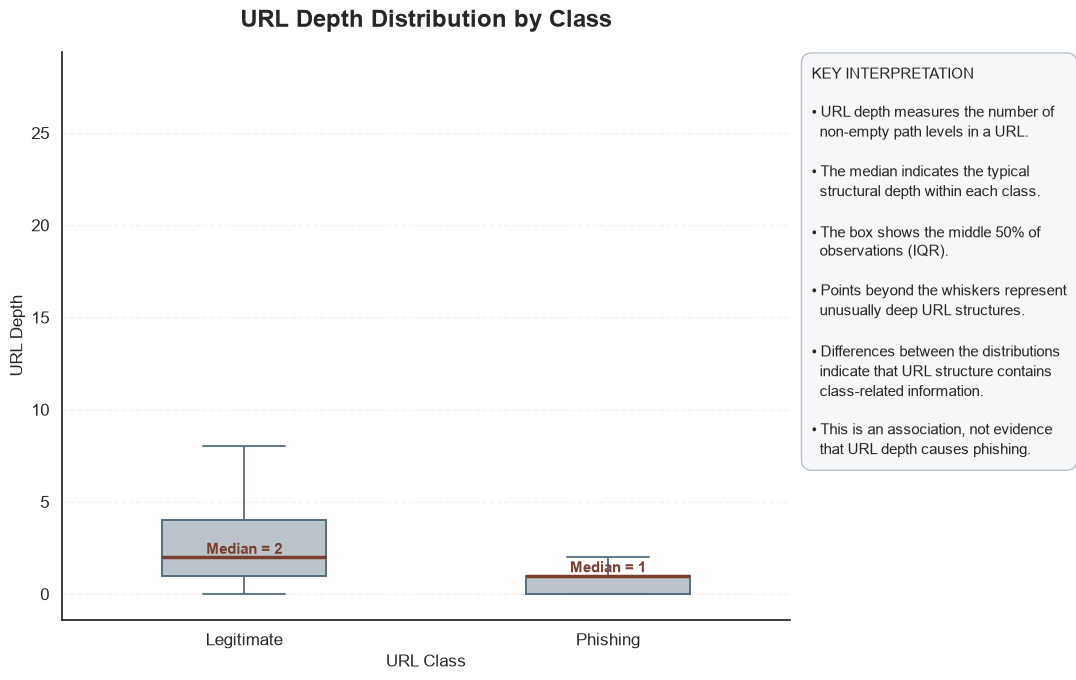


Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\url_depth_by_class_research.png


In [20]:
# STEP 37: URL DEPTH DISTRIBUTION BY CLASS
# Research-style class-wise comparison

depth_data = df.copy()

depth_data["Class"] = depth_data["Label"].map({
    0: "Legitimate",
    1: "Phishing"
})


# --------------------------------------------------
# 1. Calculate class-wise statistics
# --------------------------------------------------

depth_stats = (
    depth_data
    .groupby("Class")["URL_Depth"]
    .agg(
        Median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        Maximum="max"
    )
)

print("========== URL DEPTH STATISTICS ==========")
print(depth_stats)


# --------------------------------------------------
# 2. Figure
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 7)
)


# --------------------------------------------------
# 3. Boxplot
# --------------------------------------------------

sns.boxplot(
    data=depth_data,
    x="Class",
    y="URL_Depth",
    order=["Legitimate", "Phishing"],
    width=0.45,
    color="#B8C4CC",
    linewidth=1.4,
    fliersize=0,
    boxprops={
        "edgecolor": "#526D82"
    },
    medianprops={
        "color": "#7A3E2F",
        "linewidth": 2.5
    },
    whiskerprops={
        "color": "#526D82",
        "linewidth": 1.3
    },
    capprops={
        "color": "#526D82",
        "linewidth": 1.3
    },
    ax=ax
)


# --------------------------------------------------
# 4. Add class medians
# --------------------------------------------------

legit_median = depth_stats.loc[
    "Legitimate", "Median"
]

phish_median = depth_stats.loc[
    "Phishing", "Median"
]

ax.text(
    0,
    legit_median + 0.18,
    f"Median = {legit_median:.0f}",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="#7A3E2F"
)

ax.text(
    1,
    phish_median + 0.18,
    f"Median = {phish_median:.0f}",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="#7A3E2F"
)


# --------------------------------------------------
# 5. Labels and title
# --------------------------------------------------

ax.set_title(
    "URL Depth Distribution by Class",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "URL Class",
    fontsize=12
)

ax.set_ylabel(
    "URL Depth",
    fontsize=12
)


# --------------------------------------------------
# 6. Research interpretation
# --------------------------------------------------

insight_text = (
    "KEY INTERPRETATION\n\n"
    "• URL depth measures the number of\n"
    "  non-empty path levels in a URL.\n\n"
    "• The median indicates the typical\n"
    "  structural depth within each class.\n\n"
    "• The box shows the middle 50% of\n"
    "  observations (IQR).\n\n"
    "• Points beyond the whiskers represent\n"
    "  unusually deep URL structures.\n\n"
    "• Differences between the distributions\n"
    "  indicate that URL structure contains\n"
    "  class-related information.\n\n"
    "• This is an association, not evidence\n"
    "  that URL depth causes phishing."
)

ax.text(
    1.03,
    0.98,
    insight_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="#F5F7F8",
        edgecolor="#B8C4CC",
        linewidth=1.0
    )
)


# --------------------------------------------------
# 7. Formatting
# --------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# --------------------------------------------------
# 8. Save figure
# --------------------------------------------------

output_file = (
    FIGURE_DIR
    / "url_depth_by_class_research.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    "\nFigure saved successfully:"
)

print(output_file)

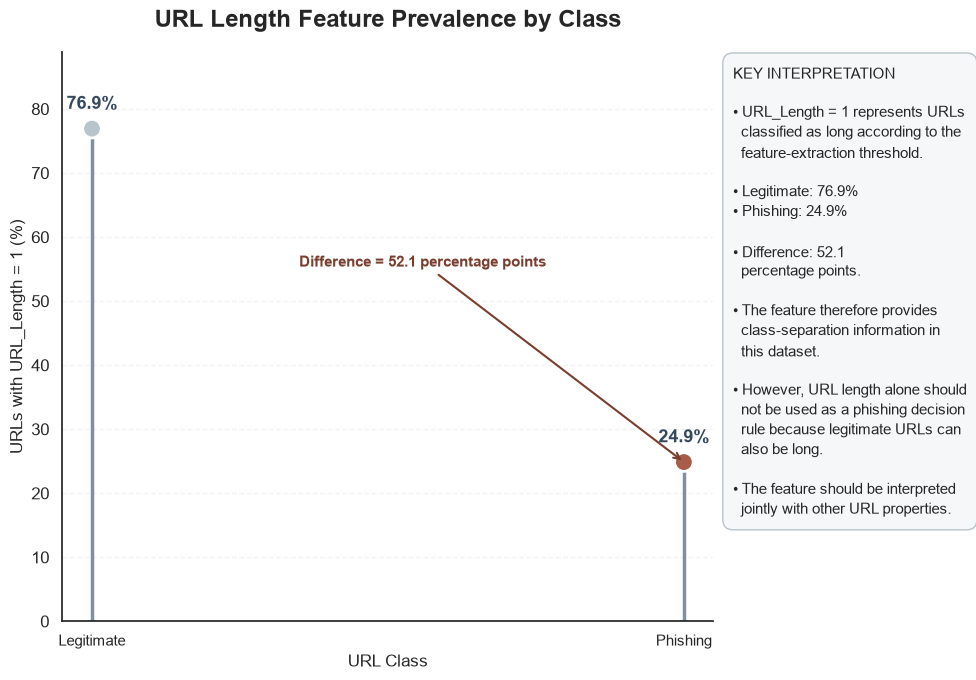

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\url_length_prevalence_by_class_research.png

========== URL LENGTH PREVALENCE ==========
Legitimate: 76.92%
Phishing: 24.86%
Difference: 52.06 percentage points


In [21]:
# STEP 38: URL LENGTH DISTRIBUTION BY CLASS
# Research-style feature prevalence analysis

length_prevalence = (
    df.groupby("Label")["URL_Length"]
    .mean()
    .mul(100)
)

legitimate_pct = length_prevalence.get(0, 0)
phishing_pct = length_prevalence.get(1, 0)

difference_pct = phishing_pct - legitimate_pct


# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 7)
)

classes = [
    "Legitimate",
    "Phishing"
]

values = [
    legitimate_pct,
    phishing_pct
]

# Subtle academic palette
palette = [
    "#B8C4CC",
    "#A85C4A"
]


# --------------------------------------------------
# Lollipop-style comparison
# --------------------------------------------------

x_positions = np.arange(len(classes))

ax.vlines(
    x_positions,
    0,
    values,
    color="#526D82",
    linewidth=2.5,
    alpha=0.75
)

ax.scatter(
    x_positions,
    values,
    s=180,
    color=palette,
    edgecolor="white",
    linewidth=2,
    zorder=3
)


# --------------------------------------------------
# Percentage labels
# --------------------------------------------------

for x, value in zip(x_positions, values):

    ax.text(
        x,
        value + 2.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color="#34495E"
    )


# --------------------------------------------------
# Difference annotation
# --------------------------------------------------

ax.annotate(
    f"Difference = {abs(difference_pct):.1f} percentage points",
    xy=(1, phishing_pct),
    xytext=(0.35, max(values) * 0.72),
    arrowprops=dict(
        arrowstyle="->",
        color="#7A3E2F",
        linewidth=1.5
    ),
    fontsize=11,
    color="#7A3E2F",
    fontweight="bold"
)


# --------------------------------------------------
# Labels
# --------------------------------------------------

ax.set_title(
    "URL Length Feature Prevalence by Class",
    fontsize=17,
    fontweight="bold",
    pad=18
)

ax.set_xlabel(
    "URL Class",
    fontsize=12
)

ax.set_ylabel(
    "URLs with URL_Length = 1 (%)",
    fontsize=12
)

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    classes,
    fontsize=11
)


# --------------------------------------------------
# Interpretation panel
# --------------------------------------------------

insight_text = (
    "KEY INTERPRETATION\n\n"
    "• URL_Length = 1 represents URLs\n"
    "  classified as long according to the\n"
    "  feature-extraction threshold.\n\n"
    f"• Legitimate: {legitimate_pct:.1f}%\n"
    f"• Phishing: {phishing_pct:.1f}%\n\n"
    f"• Difference: {abs(difference_pct):.1f}\n"
    "  percentage points.\n\n"
    "• The feature therefore provides\n"
    "  class-separation information in\n"
    "  this dataset.\n\n"
    "• However, URL length alone should\n"
    "  not be used as a phishing decision\n"
    "  rule because legitimate URLs can\n"
    "  also be long.\n\n"
    "• The feature should be interpreted\n"
    "  jointly with other URL properties."
)

ax.text(
    1.03,
    0.98,
    insight_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="#F5F7F8",
        edgecolor="#B8C4CC",
        linewidth=1.0
    )
)


# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_ylim(
    0,
    max(values) + 12
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# --------------------------------------------------
# Save
# --------------------------------------------------

output_file = (
    FIGURE_DIR
    / "url_length_prevalence_by_class_research.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    "Figure saved successfully:"
)

print(output_file)

print(
    "\n========== URL LENGTH PREVALENCE =========="
)

print(
    f"Legitimate: {legitimate_pct:.2f}%"
)

print(
    f"Phishing: {phishing_pct:.2f}%"
)

print(
    f"Difference: {abs(difference_pct):.2f} percentage points"
)

In [22]:
# STEP 39: FEATURE REDUNDANCY ANALYSIS
# Identify highly correlated feature pairs

correlation_features = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards"
]

feature_corr = df[correlation_features].corr()

# Keep only unique feature pairs
upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)

correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

correlation_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

correlation_pairs["Absolute_Correlation"] = (
    correlation_pairs["Correlation"].abs()
)

# Sort by absolute correlation
correlation_pairs = correlation_pairs.sort_values(
    "Absolute_Correlation",
    ascending=False
)

# Top 10 unique pairs
top_pairs = correlation_pairs.head(10)


# --------------------------------------------------
# Print results
# --------------------------------------------------

print("========== TOP FEATURE CORRELATION PAIRS ==========")

print(
    top_pairs[
        [
            "Feature_1",
            "Feature_2",
            "Correlation"
        ]
    ].to_string(index=False)
)


# --------------------------------------------------
# Highly correlated pairs
# --------------------------------------------------

high_corr_pairs = correlation_pairs[
    correlation_pairs["Absolute_Correlation"] >= 0.70
]

print(
    "\n========== HIGHLY CORRELATED FEATURE PAIRS =========="
)

if len(high_corr_pairs) == 0:

    print(
        "No feature pairs have |r| >= 0.70."
    )

else:

    print(
        high_corr_pairs[
            [
                "Feature_1",
                "Feature_2",
                "Correlation"
            ]
        ].to_string(index=False)
    )


# --------------------------------------------------
# Research interpretation
# --------------------------------------------------

print(
    "\n========== RESEARCH INTERPRETATION =========="
)

print(
    "A high absolute correlation indicates that two"
)

print(
    "features may contain overlapping information."
)

print(
    "This does not automatically mean that either"
)

print(
    "feature should be removed."
)

print(
    "Feature importance and model performance should"
)

print(
    "be evaluated before making feature-selection decisions."
)

========== TOP FEATURE CORRELATION PAIRS ==========
  Feature_1    Feature_2  Correlation
 Mouse_Over Web_Forwards     0.902880
 DNS_Record   Mouse_Over     0.727351
 DNS_Record Web_Forwards     0.657393
 URL_Length    URL_Depth     0.644544
 DNS_Record   Domain_Age     0.555000
 DNS_Record  Web_Traffic    -0.400306
 Domain_Age   Mouse_Over     0.390884
Web_Traffic   Mouse_Over    -0.370749
 Domain_Age Web_Forwards     0.332414
Web_Traffic Web_Forwards    -0.328229

========== HIGHLY CORRELATED FEATURE PAIRS ==========
 Feature_1    Feature_2  Correlation
Mouse_Over Web_Forwards     0.902880
DNS_Record   Mouse_Over     0.727351

========== RESEARCH INTERPRETATION ==========
A high absolute correlation indicates that two
features may contain overlapping information.
This does not automatically mean that either
feature should be removed.
Feature importance and model performance should
be evaluated before making feature-selection decisions.


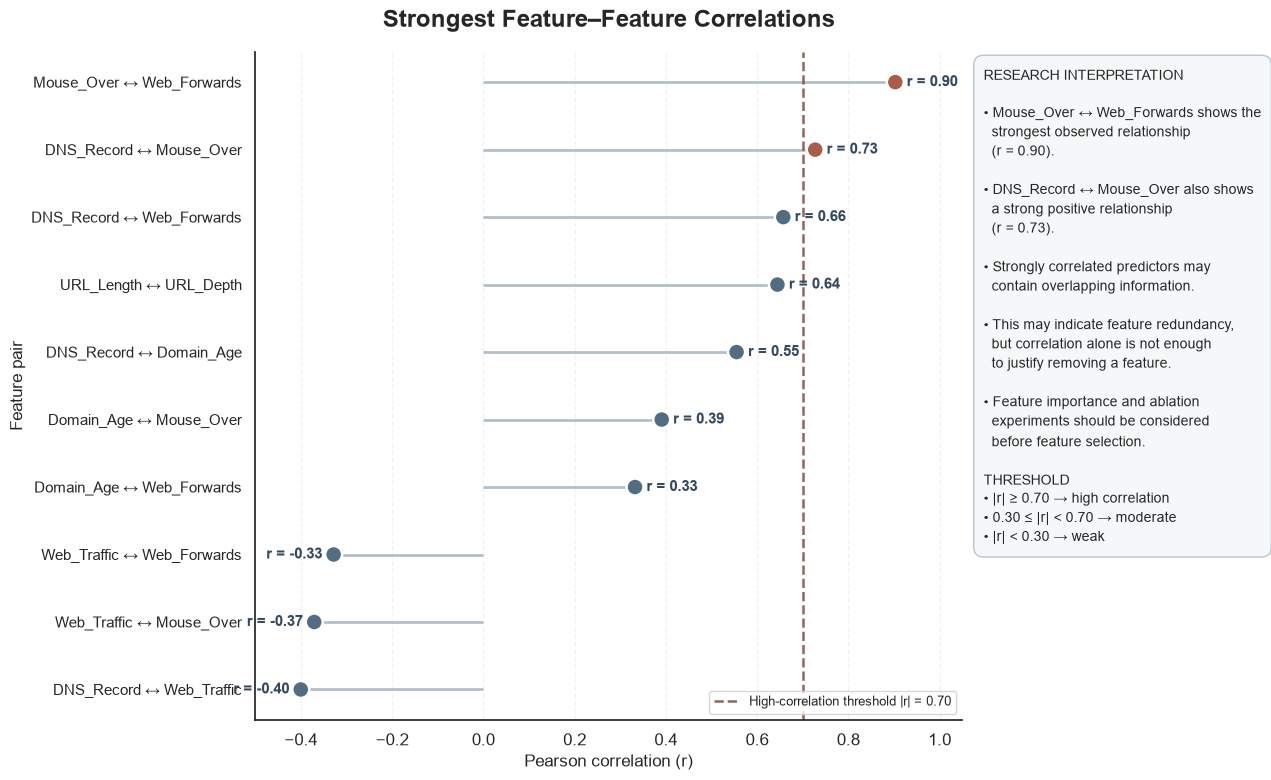

Figure saved successfully:
C:\Users\nk134\OneDrive\Desktop\coding\phishguard-x\reports\figures\top_feature_correlations_research.png


In [23]:
# STEP 40: TOP FEATURE CORRELATION PAIRS
# Research-style visualization of feature redundancy

plot_data = top_pairs.copy()

plot_data["Pair"] = (
    plot_data["Feature_1"]
    + " ↔ "
    + plot_data["Feature_2"]
)

plot_data = plot_data.sort_values(
    "Correlation",
    ascending=True
)


# --------------------------------------------------
# Figure
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(13, 8)
)

y_positions = np.arange(
    len(plot_data)
)

values = plot_data["Correlation"].values


# --------------------------------------------------
# Lollipop lines
# --------------------------------------------------

ax.hlines(
    y=y_positions,
    xmin=0,
    xmax=values,
    color="#9AAAB5",
    linewidth=2,
    alpha=0.75
)


# --------------------------------------------------
# Points
# --------------------------------------------------

point_colors = [
    "#A85C4A" if abs(value) >= 0.70
    else "#526D82"
    for value in values
]

ax.scatter(
    values,
    y_positions,
    s=150,
    color=point_colors,
    edgecolor="white",
    linewidth=1.8,
    zorder=3
)


# --------------------------------------------------
# Correlation labels
# --------------------------------------------------

for y, value in zip(
    y_positions,
    values
):

    ax.text(
        value + (0.025 if value >= 0 else -0.025),
        y,
        f"r = {value:.2f}",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=10.5,
        fontweight="bold",
        color="#34495E"
    )


# --------------------------------------------------
# High-correlation threshold
# --------------------------------------------------

ax.axvline(
    0.70,
    color="#7A3E2F",
    linestyle="--",
    linewidth=1.8,
    alpha=0.8,
    label="High-correlation threshold |r| = 0.70"
)

ax.axvline(
    -0.70,
    color="#7A3E2F",
    linestyle="--",
    linewidth=1.8,
    alpha=0.8
)


# --------------------------------------------------
# Labels
# --------------------------------------------------

ax.set_yticks(
    y_positions
)

ax.set_yticklabels(
    plot_data["Pair"],
    fontsize=10.5
)

ax.set_xlabel(
    "Pearson correlation (r)",
    fontsize=12
)

ax.set_ylabel(
    "Feature pair",
    fontsize=12
)

ax.set_title(
    "Strongest Feature–Feature Correlations",
    fontsize=17,
    fontweight="bold",
    pad=18
)


# --------------------------------------------------
# Research interpretation
# --------------------------------------------------

insight_text = (
    "RESEARCH INTERPRETATION\n\n"
    "• Mouse_Over ↔ Web_Forwards shows the\n"
    "  strongest observed relationship\n"
    f"  (r = {strongest_value:.2f}).\n\n"
    "• DNS_Record ↔ Mouse_Over also shows\n"
    "  a strong positive relationship\n"
    "  (r = 0.73).\n\n"
    "• Strongly correlated predictors may\n"
    "  contain overlapping information.\n\n"
    "• This may indicate feature redundancy,\n"
    "  but correlation alone is not enough\n"
    "  to justify removing a feature.\n\n"
    "• Feature importance and ablation\n"
    "  experiments should be considered\n"
    "  before feature selection.\n\n"
    "THRESHOLD\n"
    "• |r| ≥ 0.70 → high correlation\n"
    "• 0.30 ≤ |r| < 0.70 → moderate\n"
    "• |r| < 0.30 → weak"
)

ax.text(
    1.03,
    0.98,
    insight_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.2,
    linespacing=1.45,
    bbox=dict(
        boxstyle="round,pad=0.7",
        facecolor="#F5F7F8",
        edgecolor="#B8C4CC",
        linewidth=1.0
    )
)


# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlim(
    min(-0.05, values.min() - 0.10),
    1.05
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=9
)

sns.despine(
    ax=ax
)

plt.tight_layout()


# --------------------------------------------------
# Save
# --------------------------------------------------

output_file = (
    FIGURE_DIR
    / "top_feature_correlations_research.png"
)

fig.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(
    "Figure saved successfully:"
)

print(output_file)

In [24]:
# STEP 41: DATA QUALITY SUMMARY
# Research-style feature quality table

quality_data = []

for feature in df.columns:

    quality_data.append({
        "Feature": feature,
        "Data Type": str(df[feature].dtype),
        "Unique Values": df[feature].nunique(),
        "Missing Values": df[feature].isna().sum(),
        "Missing (%)": (
            df[feature].isna().mean() * 100
        )
    })

quality_df = pd.DataFrame(
    quality_data
)


# --------------------------------------------------
# Display
# --------------------------------------------------

print("========== DATA QUALITY SUMMARY ==========")

print(
    quality_df.to_string(index=False)
)


# --------------------------------------------------
# Overall quality statistics
# --------------------------------------------------

total_missing = df.isna().sum().sum()

total_cells = df.shape[0] * df.shape[1]

missing_percentage = (
    total_missing / total_cells
) * 100

duplicate_rows = df.duplicated().sum()


print(
    "\n========== OVERALL DATA QUALITY =========="
)

print(
    f"Total rows: {df.shape[0]:,}"
)

print(
    f"Total columns: {df.shape[1]}"
)

print(
    f"Total missing values: {total_missing:,}"
)

print(
    f"Overall missing percentage: "
    f"{missing_percentage:.2f}%"
)

print(
    f"Duplicate rows: {duplicate_rows:,}"
)


# --------------------------------------------------
# Research interpretation
# --------------------------------------------------

print(
    "\n========== RESEARCH INTERPRETATION =========="
)

if total_missing == 0:

    print(
        "• No missing values are present in the dataset."
    )

else:

    print(
        "• Missing values are present and require "
        "further treatment."
    )


print(
    "• Feature cardinality varies according to "
    "the feature representation."
)

print(
    "• Duplicate observations are retained because "
    "they are part of the constructed dataset."
)

print(
    "• Data-quality checks were performed before "
    "feature engineering and model development."
)

========== DATA QUALITY SUMMARY ==========
      Feature Data Type  Unique Values  Missing Values  Missing (%)
       Domain       str           4942               0          0.0
      Have_IP     int64              2               0          0.0
      Have_At     int64              2               0          0.0
   URL_Length     int64              2               0          0.0
    URL_Depth     int64             16               0          0.0
  Redirection     int64              2               0          0.0
 https_Domain     int64              2               0          0.0
      TinyURL     int64              2               0          0.0
Prefix/Suffix     int64              2               0          0.0
   DNS_Record     int64              2               0          0.0
  Web_Traffic     int64              2               0          0.0
   Domain_Age     int64              2               0          0.0
   Domain_End     int64              2               0          0.0
     

In [25]:
# ============================================
# CELL 18 — FEATURE-LABEL ASSOCIATION ANALYSIS
# ============================================

# Model features only
association_features = [
    "Have_IP",
    "Have_At",
    "URL_Length",
    "URL_Depth",
    "Redirection",
    "https_Domain",
    "TinyURL",
    "Prefix/Suffix",
    "DNS_Record",
    "Web_Traffic",
    "Domain_Age",
    "Domain_End",
    "iFrame",
    "Mouse_Over",
    "Web_Forwards"
]

# Pearson correlation with Label
association_data = []

for feature in association_features:
    correlation = df[feature].corr(df["Label"])

    association_data.append({
        "Feature": feature,
        "Correlation_with_Label": correlation,
        "Absolute_Correlation": abs(correlation)
    })

association_df = pd.DataFrame(association_data)

# Rank by absolute correlation
association_df = association_df.sort_values(
    by="Absolute_Correlation",
    ascending=False
).reset_index(drop=True)

print("========== FEATURE-LABEL ASSOCIATION ==========")

display(
    association_df.style
    .format({
        "Correlation_with_Label": "{:.4f}",
        "Absolute_Correlation": "{:.4f}"
    })
)

print("\n========== RESEARCH INTERPRETATION ==========")

strongest = association_df.iloc[0]

print(
    f"• Strongest linear association with Label: "
    f"{strongest['Feature']} "
    f"(r = {strongest['Correlation_with_Label']:.4f})."
)

print(
    "• Positive correlation indicates that higher feature values "
    "are associated with Label = 1 in this dataset."
)

print(
    "• Negative correlation indicates that higher feature values "
    "are associated with Label = 0 in this dataset."
)

print(
    "• Correlation measures association, not causation."
)

print(
    "• Features with weak correlation should not automatically be removed, "
    "because nonlinear models such as XGBoost can capture nonlinear interactions."
)

========== FEATURE-LABEL ASSOCIATION ==========


,Feature,Correlation_with_Label,Absolute_Correlation
0,URL_Length,-0.5181,0.5181
1,Prefix/Suffix,0.4396,0.4396
2,URL_Depth,-0.3346,0.3346
3,Domain_Age,0.3176,0.3176
4,Domain_End,0.1914,0.1914
5,Web_Traffic,-0.1529,0.1529
6,DNS_Record,0.1023,0.1023
7,iFrame,0.1017,0.1017
8,Web_Forwards,-0.0596,0.0596
9,Have_IP,0.0319,0.0319



========== RESEARCH INTERPRETATION ==========
• Strongest linear association with Label: URL_Length (r = -0.5181).
• Positive correlation indicates that higher feature values are associated with Label = 1 in this dataset.
• Negative correlation indicates that higher feature values are associated with Label = 0 in this dataset.
• Correlation measures association, not causation.
• Features with weak correlation should not automatically be removed, because nonlinear models such as XGBoost can capture nonlinear interactions.


In [26]:
# ============================================
# CELL 19 — CLASS-WISE DESCRIPTIVE STATISTICS
# ============================================

class_stats = (
    df.groupby("Label")[association_features]
      .agg(["mean", "std", "median"])
      .round(4)
)

# Readable class names
class_stats.index = ["Legitimate", "Phishing"]

print("========== CLASS-WISE DESCRIPTIVE STATISTICS ==========")

display(class_stats)

print("\n========== RESEARCH INTERPRETATION ==========")

print(
    "• Mean represents the average feature value within each class."
)

print(
    "• Standard deviation indicates the variability of the feature within each class."
)

print(
    "• Median represents the central observation and is less affected by extreme values."
)

print(
    "• Differences between class-level statistics indicate distributional differences, "
    "but they do not by themselves establish causation."
)

========== CLASS-WISE DESCRIPTIVE STATISTICS ==========


Have_IP                Have_At                URL_Length          \
              mean     std median    mean     std median       mean     std   
Legitimate  0.0000  0.0000    0.0  0.0037  0.0607    0.0     0.7692  0.4214   
Phishing    0.0018  0.0424    0.0  0.0056  0.0746    0.0     0.2486  0.4322   

                  URL_Depth  ... Domain_End  iFrame                Mouse_Over  \
           median      mean  ...     median    mean     std median       mean   
Legitimate    1.0    2.5429  ...        1.0  0.8069  0.3947    1.0     0.2257   
Phishing      0.0    1.1350  ...        1.0  0.8822  0.3224    1.0     0.2316   

                          Web_Forwards                 
               std median         mean     std median  
Legitimate  0.4181    0.0       0.2889  0.4533    0.0  
Phishing    0.4219    0.0       0.2358  0.4245    0.0  

[2 rows x 45 columns]


========== RESEARCH INTERPRETATION ==========
• Mean represents the average feature value within each class.
• Standard deviation indicates the variability of the feature within each class.
• Median represents the central observation and is less affected by extreme values.
• Differences between class-level statistics indicate distributional differences, but they do not by themselves establish causation.


In [30]:
# ============================================
# CELL 20 — CHI-SQUARE SIGNIFICANCE TEST
# ============================================

from scipy.stats import chi2_contingency

chi_square_results = []

for feature in binary_features:

    contingency_table = pd.crosstab(
        df[feature],
        df["Label"]
    )

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_square_results.append({
        "Feature": feature,
        "Chi2": chi2,
        "p_value": p_value,
        "Significant_0.05": p_value < 0.05
    })

chi_square_df = pd.DataFrame(chi_square_results)

# Rank by statistical strength
chi_square_df = chi_square_df.sort_values(
    by="p_value",
    ascending=True
).reset_index(drop=True)

print("========== CHI-SQUARE SIGNIFICANCE TEST ==========")

display(
    chi_square_df.style.format({
        "Chi2": "{:.4f}",
        "p_value": "{:.6f}"
    })
)

print("\n========== SIGNIFICANT FEATURES (p < 0.05) ==========")

significant_features = chi_square_df[
    chi_square_df["Significant_0.05"]
]["Feature"].tolist()

print(significant_features)

print("\n========== RESEARCH INTERPRETATION ==========")

print(
    "• H0: The feature and Label are statistically independent."
)

print(
    "• H1: The feature and Label have a statistically significant association."
)

print(
    "• A p-value below 0.05 indicates evidence against the independence assumption."
)

print(
    "• Statistical significance does not imply causation or high predictive importance."
)

print(
    "• Features are retained or removed based on the complete feature-engineering "
    "and model-evaluation process, not p-value alone."
)

========== CHI-SQUARE SIGNIFICANCE TEST ==========


,Feature,Chi2,p_value,Significant_0.05
0,URL_Length,3084.7099,0.000000,True
1,Prefix/Suffix,2219.5440,0.000000,True
2,Domain_Age,1158.3520,0.000000,True
3,Domain_End,420.4809,0.000000,True
4,Web_Traffic,268.2219,0.000000,True
5,DNS_Record,119.7432,0.000000,True
6,iFrame,118.3867,0.000000,True
7,Web_Forwards,40.5936,0.000000,True
8,Have_IP,9.5205,0.002032,True
9,TinyURL,3.6120,0.057364,False



========== SIGNIFICANT FEATURES (p < 0.05) ==========
['URL_Length', 'Prefix/Suffix', 'Domain_Age', 'Domain_End', 'Web_Traffic', 'DNS_Record', 'iFrame', 'Web_Forwards', 'Have_IP']

========== RESEARCH INTERPRETATION ==========
• H0: The feature and Label are statistically independent.
• H1: The feature and Label have a statistically significant association.
• A p-value below 0.05 indicates evidence against the independence assumption.
• Statistical significance does not imply causation or high predictive importance.
• Features are retained or removed based on the complete feature-engineering and model-evaluation process, not p-value alone.


In [31]:
# ============================================
# CELL 21 — FEATURE VARIANCE CHECK
# ============================================

variance_df = (
    df[association_features]
    .var()
    .sort_values(ascending=True)
    .reset_index()
)

variance_df.columns = ["Feature", "Variance"]

print("========== FEATURE VARIANCE ==========")

display(
    variance_df.style.format({
        "Variance": "{:.6f}"
    })
)

print("\n========== CONSTANT FEATURES ==========")

constant_features = variance_df[
    variance_df["Variance"] == 0
]["Feature"].tolist()

print(constant_features)

print("\n========== NEAR-CONSTANT FEATURES ==========")

# A practical screening threshold
near_constant_threshold = 0.01

near_constant_features = variance_df[
    (variance_df["Variance"] > 0) &
    (variance_df["Variance"] < near_constant_threshold)
]["Feature"].tolist()

print(near_constant_features)

print("\n========== RESEARCH INTERPRETATION ==========")

if constant_features:
    print(
        f"• Constant feature(s) detected: {constant_features}"
    )
else:
    print("• No constant features detected.")

if near_constant_features:
    print(
        f"• Near-constant feature(s) below variance threshold "
        f"({near_constant_threshold}): {near_constant_features}"
    )
else:
    print(
        f"• No near-constant features detected below "
        f"variance threshold {near_constant_threshold}."
    )

print(
    "• Variance screening is used as a diagnostic step and "
    "does not determine predictive importance by itself."
)

========== FEATURE VARIANCE ==========


,Feature,Variance
0,https_Domain,0.000087
1,Have_IP,0.000782
2,Have_At,0.004502
3,Redirection,0.012874
4,TinyURL,0.059226
5,DNS_Record,0.117007
6,iFrame,0.134648
7,Prefix/Suffix,0.136296
8,Domain_End,0.144020
9,Mouse_Over,0.176173



========== CONSTANT FEATURES ==========
[]

========== NEAR-CONSTANT FEATURES ==========
['https_Domain', 'Have_IP', 'Have_At']

========== RESEARCH INTERPRETATION ==========
• No constant features detected.
• Near-constant feature(s) below variance threshold (0.01): ['https_Domain', 'Have_IP', 'Have_At']
• Variance screening is used as a diagnostic step and does not determine predictive importance by itself.
